<a href="https://colab.research.google.com/github/Varshini-Anand/Nunnariacademy_Datasciencewithaibootcamp/blob/main/Nunnari_Academy_DS_with_AI_Bootcamp_Day_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Titanic Survival Prediction**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('/content/sample_data/train.csv')

In [3]:
# Handling Missing Values
# Fill Age with the median to avoid outliers affecting the mean
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with the most common port (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# --- Encoding Categorical Data ---
# Convert 'Sex' to numeric: male=0, female=1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Bonus: One-Hot Encoding for 'Embarked'
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Bonus Challenge: Feature Engineering
# Create 'FamilySize' by combining siblings (SibSp) and parents (Parch)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create 'IsAlone' feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [4]:
# Selecting features based on the task + bonus features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
X = df[features]
y = df['Survived']

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bonus: Feature Scaling
# Logistic Regression converges faster and performs better with scaled data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

✅ Accuracy Score: 80.45%

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



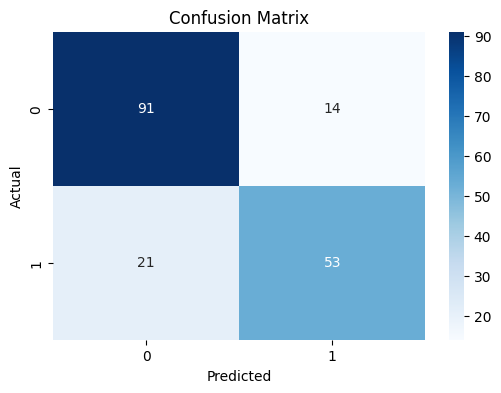

In [5]:
# Initialize and Train the Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

#  Evaluation Metrics
print(f"✅ Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()